# Fourier Transform (20 points)
### 1. Load a grayscale image and apply the 2D Discrete Fourier Transform (DFT) to it. Visualize the original image and its frequency spectrum (magnitude). Submit the images, and explanation.

In [74]:
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Locate the path to the dataset
base_path = Path("..") / "data" / "vehicle-type-detection" 

dataset = datasets.ImageFolder(
    base_path,
)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(dataset.classes)

['hatchback', 'motorcycle', 'pickup', 'sedan', 'suv']


In [75]:
image, label = dataset[3]  # Selects the first image

gray_image = image.convert("L")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to NumPy array
image_data = np.array(gray_image)
image_fft = np.fft.fft2(image_data)
image_fft = np.fft.fftshift(image_fft)

# Magnitude of the complex DFT
magnitude = np.abs(image_fft)

# Logarithmic scaling
dft_image = np.log10(magnitude + 1)

# Normalize to [0, 1]
dft_image /= dft_image.max()

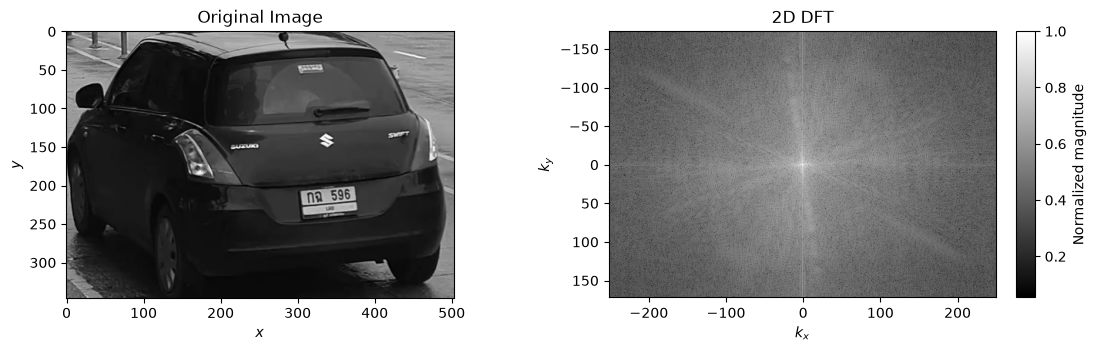

In [77]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

height, width = image_data.shape

kx = np.arange(-width // 2, width // 2)
ky = np.arange(-height // 2, height // 2)

fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.4
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Original image
ax1.imshow(
    image_data,
    cmap="gray",
    aspect="equal"
)
ax1.set_title("Original Image")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")

# DFT
im = ax2.imshow(
    dft_image,
    cmap="gray",
    aspect="equal",
    extent=[
        kx[0], kx[-1],
        ky[-1], ky[0]
    ]
)
ax2.set_title("2D DFT")
ax2.set_xlabel("$k_x$")
ax2.set_ylabel("$k_y$")

# Short colorbar
cax = inset_axes(
    ax2,
    width="5%",
    height="100%",
    loc="center left",
    bbox_to_anchor=(1.05, 0, 1, 1),
    bbox_transform=ax2.transAxes,
    borderpad=0
)

fig.colorbar(
    im,
    cax=cax,
    label="Normalized magnitude"
)

plt.savefig("dft_visualization.pdf", bbox_inches="tight")
plt.show()

The 2D Fourier transform is strongest at the center, indicating dominant low-frequency components from the image’s overall structure and brightness. The rays extending from the center represent higher-frequency components caused by edges and directional features. 

### 2. Implement a low-pass filter in the frequency domain to remove high-frequency noise from an image. Compare the filtered image with the original image. Submit images, and analysis of the results.

In [78]:
def low_pass_filter(dft, ratio=0.5):
    rows, cols = dft.shape

    y, x = np.ogrid[:rows, :cols]

    cx, cy = cols // 2, rows // 2

    distance = np.sqrt((x - cx)**2 + (y - cy)**2)

    cutoff = ratio * min(rows, cols) / 2

    return dft * (distance <= cutoff)
    
    
dft_filtered = low_pass_filter(image_fft, ratio=0.5)

# Inverse FFT
filtered_image = np.real(
    np.fft.ifft2(np.fft.ifftshift(dft_filtered))
)

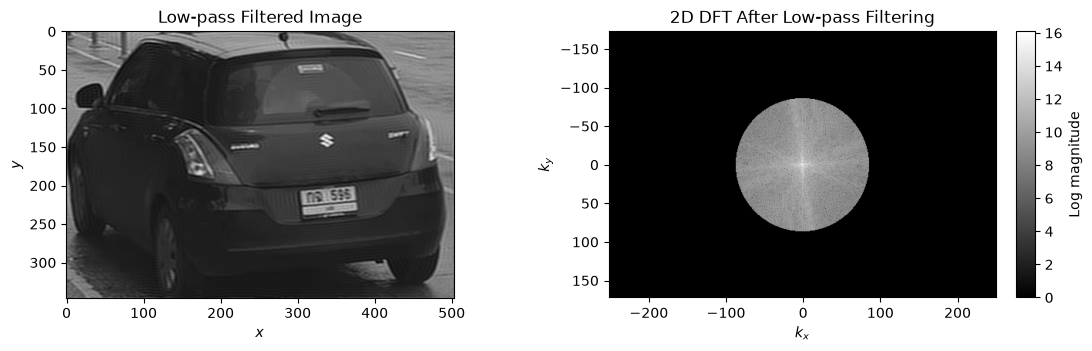

In [79]:
# Normalize ONLY for displaying
display_image = (
    filtered_image - filtered_image.min()
) / (
    filtered_image.max() - filtered_image.min()
)

fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.4
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1.imshow(
    display_image,
    cmap="gray",
    vmin=0, 
    vmax=1
)

ax1.set_title("Low-pass Filtered Image")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")

dft_magnitude = np.log1p(np.abs(dft_filtered))

im = ax2.imshow(
    dft_magnitude,
    cmap="gray",
    aspect="equal",
    extent=[
        kx[0], kx[-1],
        ky[-1], ky[0]
    ]
)

ax2.set_title("2D DFT After Low-pass Filtering")
ax2.set_xlabel("$k_x$")
ax2.set_ylabel("$k_y$")

cax = inset_axes(
    ax2,
    width="5%",
    height="100%",
    loc="center left",
    bbox_to_anchor=(1.05, 0, 1, 1),
    bbox_transform=ax2.transAxes,
    borderpad=0
)

fig.colorbar(
    im,
    cax=cax,
    label="Log magnitude"
)

plt.savefig("lowpass_visualization.pdf", bbox_inches="tight")

plt.show()

In [80]:
def high_pass_filter(dft, ratio=0.5):
    rows, cols = dft.shape

    y, x = np.ogrid[:rows, :cols]

    cx, cy = cols // 2, rows // 2

    distance = np.sqrt((x - cx)**2 + (y - cy)**2)

    cutoff = ratio * min(rows, cols) / 2

    return dft * (distance >= cutoff)

dft_filtered = high_pass_filter(image_fft, ratio=0.3)

# Inverse FFT
filtered_image = np.real(
    np.fft.ifft2(np.fft.ifftshift(dft_filtered))
)

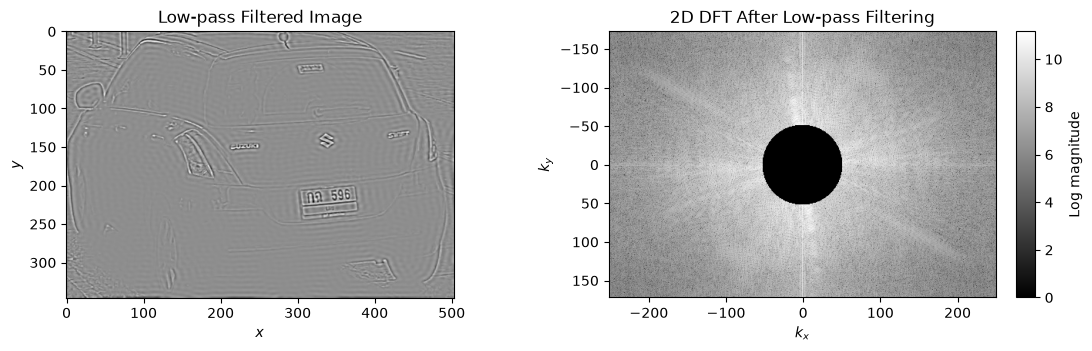

In [81]:
# Normalize ONLY for displaying
display_image = (
    filtered_image - filtered_image.min()
) / (
    filtered_image.max() - filtered_image.min()
)

fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.4
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1.imshow(
    display_image,
    cmap="gray",
    vmin=0, 
    vmax=1
)

ax1.set_title("Low-pass Filtered Image")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")

dft_magnitude = np.log1p(np.abs(dft_filtered))

im = ax2.imshow(
    dft_magnitude,
    cmap="gray",
    aspect="equal",
    extent=[
        kx[0], kx[-1],
        ky[-1], ky[0]
    ]
)

ax2.set_title("2D DFT After Low-pass Filtering")
ax2.set_xlabel("$k_x$")
ax2.set_ylabel("$k_y$")

cax = inset_axes(
    ax2,
    width="5%",
    height="100%",
    loc="center left",
    bbox_to_anchor=(1.05, 0, 1, 1),
    bbox_transform=ax2.transAxes,
    borderpad=0
)

fig.colorbar(
    im,
    cax=cax,
    label="Log magnitude"
)

plt.savefig("lowpass_visualization.pdf", bbox_inches="tight")

plt.show()

In [82]:
def compress_fourier(dft, percentage):
    magnitude = np.abs(dft)

    # Find the magnitude threshold
    threshold = np.percentile(
        magnitude,
        100 - percentage
    )

    # Keep only coefficients above threshold
    mask = magnitude >= threshold

    return dft * mask

dft_10 = compress_fourier(image_fft, 10)

image_10 = np.real(
    np.fft.ifft2(
        np.fft.ifftshift(dft_10)
    )
)

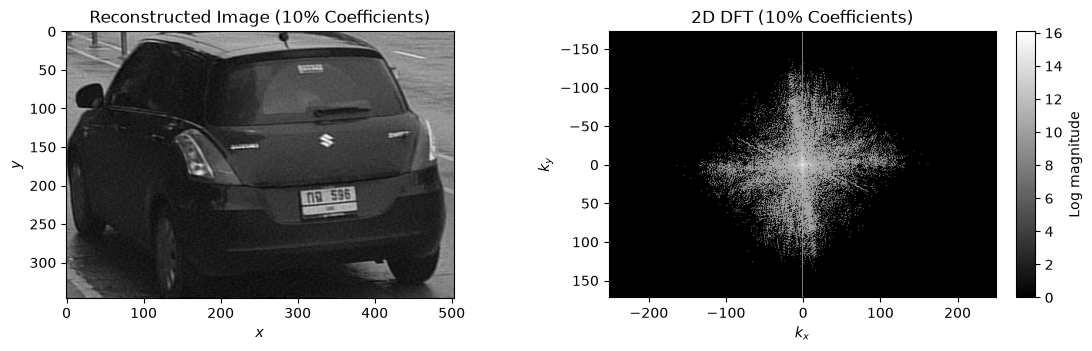

In [83]:
image_10_display = (
    image_10 - image_10.min()
) / (
    image_10.max() - image_10.min()
)

fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.4
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Reconstructed image
ax1.imshow(
    image_10_display,
    cmap="gray",
    vmin=0,
    vmax=1
)

ax1.set_title("Reconstructed Image (10% Coefficients)")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")

# Compressed 2D DFT
dft_magnitude = np.log1p(np.abs(dft_10))

im = ax2.imshow(
    dft_magnitude,
    cmap="gray",
    aspect="equal",
    extent=[
        kx[0], kx[-1],
        ky[-1], ky[0]
    ]
)

ax2.set_title("2D DFT (10% Coefficients)")
ax2.set_xlabel("$k_x$")
ax2.set_ylabel("$k_y$")

# Colorbar
cax = inset_axes(
    ax2,
    width="5%",
    height="100%",
    loc="center left",
    bbox_to_anchor=(1.05, 0, 1, 1),
    bbox_transform=ax2.transAxes,
    borderpad=0
)

fig.colorbar(
    im,
    cax=cax,
    label="Log magnitude"
)

plt.savefig(
    "fourier_compression_10_percent.pdf",
    bbox_inches="tight"
)

plt.show()
